In [37]:
# Importing needed code

from pathlib import Path
from typing import Callable, Literal
from datetime import datetime, time, date, timedelta
from dataclasses import dataclass

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import statistics as stat

from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier, bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.signal import savgol_filter

# Load Data

In [2]:
# Defining variables for important ARC folders

alloc_code = 'st-cberling-1'
project_folder = Path('/arc/project') / alloc_code
scratch_folder = Path('scratch') / alloc_code
input_data_folder = project_folder / 'input_data'

In [3]:
# Location of PSD data folder; change as needed
PARQ_ROOT = input_data_folder / 'E-cell_Fusion_1_Jan19-2023/processed_data/unfiltered/psd'

In [4]:
%%time
# Load PSD data to "psd_report" DataFrame
psd_report = pd.read_parquet(PARQ_ROOT, columns=["CALIB_ENERGY","ENERGYSHORT", "ENERGY", "TIMETAG"])
psd_report = psd_report.astype({"CALIB_ENERGY": float, "ENERGYSHORT": int, "ENERGY": int, "TIMETAG": np.int64})

# Calculate PSD value as new column "tail / total"
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report = psd_report.dropna()
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]
psd_report.head()

CPU times: user 2.41 s, sys: 492 ms, total: 2.9 s
Wall time: 3.02 s


,CALIB_ENERGY,ENERGYSHORT,ENERGY,TIMETAG,tail / total
0,0.763886,923,1088,9065858213,0.151654
1,0.255336,319,361,12179764722,0.116343
2,0.068829,77,94,23233068983,0.180851
3,0.223193,257,315,27488491909,0.184127
4,0.222495,268,314,56264741099,0.146497


In [5]:
%%time
# Generate random sample of "psd_report" for graphing
# Graphing 300M points is way too slow, so best to graph a reasonable fraction of all points

sample_frac = 0.1  # fraction of points to put in sample (0-1)
random_state = 1323  # random number generator seed; change to try different samples

if sample_frac >= 1:
    graph_sample = psd_report
else:
    graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 131 ms, sys: 862 µs, total: 132 ms
Wall time: 136 ms


In [6]:
# Define plotting variables

fontsize = 24
label_size = 22

## Heatmap & Histograms

In [7]:
# Create 2D histogram of PSD vs Energy data
# Generates 2D grid of "bins

resolution = int(1024/2)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

In [8]:
# Find energy slice width
energy_slice_width = xe[2] - xe[1]
f"Energy Slice Width = {energy_slice_width:.4f} MeVee"

'Energy Slice Width = 0.0056 MeVee'

# FOM Analysis

In [9]:
# TODO delete this when we get window using Californium source
# but keep in a FOM analysis notebook for when we need to recalibrate window

In [10]:
# FOM function definition

BimodalParams = tuple[float, float, float, float, float, float]
GaussianParams = tuple[float, float, float]
BimodalBounds = tuple[BimodalParams, BimodalParams]

def split_params(
    params: BimodalParams
) -> tuple[GaussianParams, GaussianParams]:
    """Separates bimodal function parameters into 2 sets, one per component gaussian
    
    Parameters
    ----------
    params: BimodalParams
        parameters of a bimodal function
        
    Returns
    -------
    lower_gaussian_params: GaussianParams
        parameters of the lower gaussian (i.e. lower mu value)
    upper_gaussian_params: GaussianParams
        parameters of the upper gaussian (i.e. higher mu value)
    """
    params = abs(params)
    return params[0:3], params[3:]

def get_bimodal_fit(
    bins: np.ndarray, 
    histogram_slice: np.ndarray, 
    bounds: BimodalBounds
) -> tuple[GaussianParams, GaussianParams, np.ndarray]:
    """Fits a histogram slice to a bimodal distribution
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram_slice: ndarray
        slice of the 2D PSD/Energy histogram taken for a specific energy (i.e. PSD vs Counts)
    bounds: BimodalBounds
        lower and upper bounds of fit parameters for this slice
        
    Returns
    -------
    gamma_params: GaussianParams
        parameters of the gaussian fit for gamma rays
    neutron_params: GaussianParams
        parameters of the gaussian fit for neutrons
    cov: ndarray
        estimated covariance of all bimodial parameters
    """
    params, cov = curve_fit(
        bimodal,
        bins,
        histogram_slice,
        bounds=bounds,
    )
    
    gamma_params, neutron_params = split_params(params)
    
    return gamma_params, neutron_params, cov


def scan_histogram_slices(
    bins: np.ndarray, 
    histogram: np.ndarray, 
    default_bounds: BimodalBounds,
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None = None, 
    start_idx: int = 0, 
    end_idx: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Determines bimodal fit and FOM for every energy slice in 2D PSD/Energy histogram
    
    Parameters
    ----------
    bins: ndarray
        lower bounds of each PSD bin in the histogram
    histogram: ndarray
        2D PSD/Energy histogram
    default_bounds: BimodalBounds
        default lower and upper bounds of fit parameters
    bounds: list[tuple[tuple[int, int], BimodalBounds]] | None, default None
        allows custom bounds for slice ranges. 
        Each list entry must have a tuple of start and stop indexes, and corresponding fit bounds.
        Bounds are used when the slice index falls within the start/stop range (start inclusive, stop exclusive).
        If index ranges overlap, the last matching range is used.
        If bounds is None, only default_bounds are used.
    start_idx: int, default 0
        starting index (inclusive) of slice range to fit to bimodal
    end_idx: int | None, default None
        ending index (exclusive) of slice range to fit to bimodal
        
    Returns
    -------
    fit_dataframe: DataFrame
        DataFrame of fit parameters including FOM (as columns) for each slice (as rows)
    error_dataframe: DataFrame
        DataFrame of (1 standard deviation) errors in fit parameters (as columns) for each slice (as rows)
    """
    end_idx = len(histogram) if end_idx is None else min(len(histogram), end_idx)
        
    slice_params = []
    slice_err = []
    
    for i in range(start_idx, end_idx):
        fit_bounds = default_bounds
        
        if bounds is not None :
            for i_range, bound in bounds:
                if i in range(*i_range):
                    fit_bounds = bound
        
#         print(f"default = {default_bounds}\nbounds={bounds}")
        gamma_params, neutron_params, cov = get_bimodal_fit(bins, histogram[:,i], fit_bounds)
        
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        
        perr = np.sqrt(np.diag(cov))
    
        slice_params.append((i, *gamma_params, *neutron_params, fom))
        slice_err.append((i, *perr))
    
    columns = ['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2']
    df = pd.DataFrame(slice_params, columns=columns + ['fom'])
    err_df = pd.DataFrame(slice_err, columns=columns)
    
    return df, err_df

In [11]:
%%time
# Scan 2D histogram's energy slices and get bimodal fit

psd_bin_lbs = ye[:-1]

# Default
default_bounds = (
    (0.1, 0.01, 1, 
     0.25, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.38, 0.04, 2000)
)

bounds_a = (
    (0.1, 0.01, 1, 
     0.35, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.04, 2000)
)

bounds_b = (
    (0.1, 0.01, 1, 
     0.34, 0.01, 0),
    (0.2, 0.1, Z.max(),
     0.36, 0.03, 2000)
)


# Ranged Example
bounds = [
    ((0,60), bounds_a),
]

start_scan_idx = 0
end_scan_idx = 420

end_scan_idx = min(end_scan_idx, len(Z))

# df_fom = find_threshold_fom_slice(psd_bin_lbs, Z.T, bounds, 0, end_scan_idx)

df, df_err = scan_histogram_slices(
    psd_bin_lbs, 
    Z.T,
    bounds=bounds,
    default_bounds=default_bounds, 
    start_idx = start_scan_idx, 
    end_idx = end_scan_idx
)


df.head()

CPU times: user 7.9 s, sys: 95.7 ms, total: 8 s
Wall time: 8.04 s


,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.142626,0.01,1.0,0.350000,0.031601,1.161229e-01,2.116853
1,1,0.149889,0.01,1.0,0.354779,0.010000,4.546592e-05,4.350445
2,2,0.149889,0.01,1.0,0.354779,0.010000,4.546592e-05,4.350445
3,3,0.149880,0.01,1.0,0.354779,0.010000,4.546591e-05,4.350636
4,4,0.132315,0.01,1.0,0.354779,0.010000,4.357633e-11,4.723593


In [12]:
# TODO get L0 from Californium source analysis
# for now, using value from "UBC Background 20221214-19 Update"
# TODO change this variable name to something more descriptive
L0 = 0.1966

# Counting Windows

In [13]:
# Window fitting function definition

window_adj_offset = 0

def classify(
    psd_report: pd.DataFrame, 
    lb_fit_fn: Callable[[np.ndarray], np.ndarray], 
    ub_fit_fn: Callable[[np.ndarray], np.ndarray], 
    label: str, 
    le_cutoff: float = L0
) -> pd.DataFrame:
    """Classify signals as neutron or non-neutron for a given count window
    Classification creates a new column of boolean values, where True indicates a neutron classified signal.
    
    Parameters
    ----------
    psd_report: DataFrame
        DataFrame containing signal PSD data. 
        It must have the "tail / total" (for PSD value) and "CALIB_ENERGY" (for calibrated energy) columns.
    lb_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's lower bounds
    ub_fit_fn: Callable[[ndarray], ndarray]
        A function describing the window's upper bounds
    label: str
        column label to use for signal classification results
    le_cutoff: float, default L0 (previously determined lower energy cutoff)
        Lower energy cutoff (AKA the left boundary of the neutron window)
        
    Returns
    -------
    psd_report: DataFrame
        Original DataFrame with new column for neutron classification
    """
    psd_report[label] = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)) + 
        window_adj_offset, ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    ) & (psd_report["CALIB_ENERGY"] >= le_cutoff)
    
    return psd_report

def plot_classification(
    neutrons: pd.DataFrame, 
    gammas: pd.DataFrame, 
    lb_fit: Callable[[float], float],
    ub_fit: Callable[[float], float],
    max_energy: float,
    FOM_cutoff: float,
    n_neutrons: int,
    label_n: str = "Neutrons",
    label_g: str = "Non-Neutrons",
) -> tuple[plt.Figure, plt.Axes]:
    """Plot detected events, showing neutron classification window
    The classification window's upper and lower PSD bound functions, as well as the energy cutoff (left side) bound,
    are shown as dotted lines. Points are color labelled to show neutron vs. non-neutron events.
    
    Parameters
    ----------
    neutrons: pd.DataFrame
        DataFrame of neutron classified events to display
    gammas: pd.DataFrame
        DataFrame of non-neutron classified events to display (assumed to be gamma rays)
    lb_fit, ub_fit: Callabl[[float], float]
        Lower and upper PSD bound functions
    max_energy: float
        maximum energy used in this plot (which determines x-axis range)
    FOM_cutoff: float
        energy cutoff, i.e. lowest energy where FOM > 1.27
    n_neutrons: int
        Actual total number of neutrons (to be displayed in title)
        This parameter is used rather than obtained from the neutrons DataFrame
        to allow data samples to be plotted for faster plotting.
    label_n: str
        Series label for neutron classified events
    label_g: str
        Series label for non-neutron classified events (AKA gamma rays)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for neutron classification plot
    ax: plt.Axes
        plot axes for neutron classification plot
    
    """
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label=label_g)
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label=label_n)

    energy_space = np.linspace(xe[0], max_energy + 0.5, 200)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'r', ls="--")

    ax.set_title(f"Counts = {n_neutrons}", fontsize=fontsize)
    ax.set_ylim(0, 0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

In [14]:
# Define variable for all slice indexes to use
# (can be overridden if you only want to plot a subset of x axis)

all_slice_xs = xe[:end_scan_idx]

## NASA  


This classification window is based on the technique outlined in _Fast Neutron Spectroscopy With Organic Scintillation Detectors in a High-Radiation Environment_, Baramsai _et al_.

We define the lower PSD bound as N standard deviations above the gamma mean. We find these points for each slice, then use smoothing and interpolation to generate a lower bound function.

The upper bound for the window is generated by adding a fixed offset to the lower bound value (found to be 0.2 based on observation of the paper's graphs).

As in all windows, the FOM cutoff is used as the left-most bound.

In [15]:
# Define lower and upper bounds (neutron_lb_fit, neutron_ub_fit)

window_offset = 0.2
sigma = 5

neutron_lb = savgol_filter(df["mu1"] + sigma * df["sigma1"], window_length=21, polyorder=3)  # reduce noise
neutron_lb_fit = interp1d(
    all_slice_xs, 
    neutron_lb, 
    fill_value=(neutron_lb[0], neutron_lb[-1]), 
    bounds_error=False)  # now it's a function!

def neutron_ub_fit(x):
    # upper bound is just a fixed PSD offset from lower bound
    # as observed in NASA paper graphs
    return neutron_lb_fit(x) + window_offset

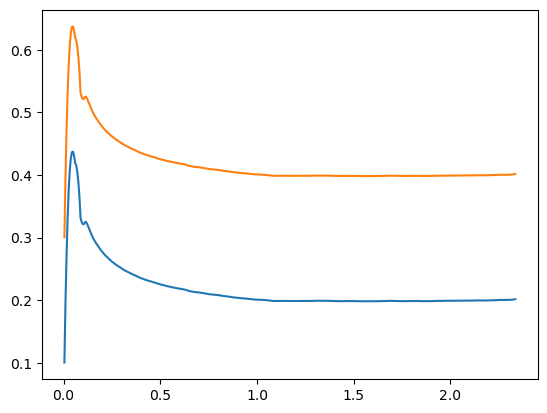

In [16]:
# Plot upper and lower bounds (diagnostic)

plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [17]:
%%time
# Classify neutrons under NASA window
psd_report = classify(psd_report, neutron_lb_fit, neutron_ub_fit, "NASA",le_cutoff=L0)

CPU times: user 383 ms, sys: 13.2 ms, total: 397 ms
Wall time: 401 ms


In [18]:
%%time
# Recreate graph sample with classification data
del graph_sample
graph_sample = psd_report.sample(frac=sample_frac,random_state=random_state)

CPU times: user 135 ms, sys: 1.92 ms, total: 137 ms
Wall time: 141 ms


CPU times: user 46.7 ms, sys: 1.01 ms, total: 47.7 ms
Wall time: 47.9 ms


(<Figure size 1000x1000 with 1 Axes>,
 <AxesSubplot: title={'center': 'Counts = 3205'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

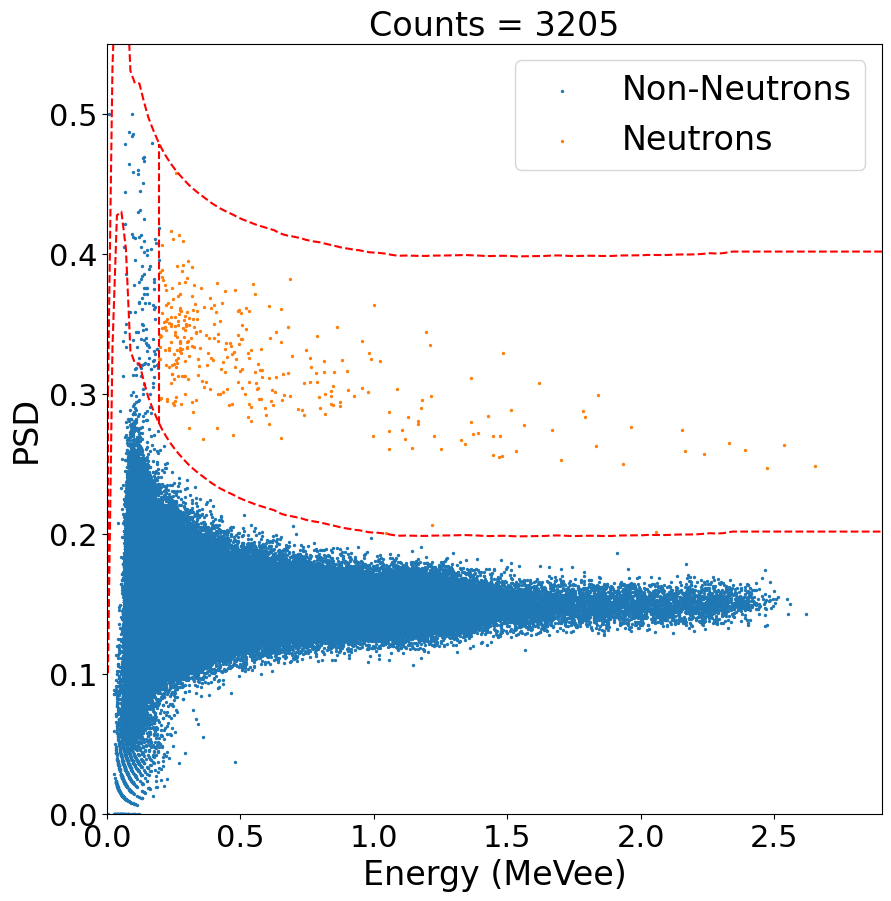

In [19]:
%%time
# Plotting NASA classification
plot_classification(
    graph_sample[graph_sample["NASA"]], 
    graph_sample[~graph_sample["NASA"]], 
    neutron_lb_fit, 
    neutron_ub_fit, 
    psd_report["CALIB_ENERGY"].max(), 
    L0,
    psd_report[psd_report["NASA"]].shape[0]
)


# plt.plot(all_slice_xs, df["mu2"])
# plt.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"])
# plt.xlim(0.2,0.4)
# plt.ylim(0.3, 0.5)

# CPS

In [70]:
%%time
# Defining count rate functions

# TODO redevelop to work with on/off time ranges
# any counts outside the ranges should be NaN
def counts_over_time_histogram(
    timetags: pd.Series, 
    dwell_time: int, 
    start_timestamp: int,
    end_timestamp: int
) -> tuple[np.ndarray, np.ndarray]:
    """Generates histogram of event counts per dwell time bin over a time period
    
    Parameters
    ----------
    timetags: pd.Series
        timetags (as picoseconds after neutron detector start) for all relevant events 
    dwell_time: int
        time period used for histogram bin width in seconds
    start_timestamp: int
        starting timestamp (as picoseconds after neutron detector start) for histogram period
    end_timestamp: int
        ending timestamp (as picoseconds after neutron detector start) for histogram period
    
        
    Returns
    -------
    counts: np.ndarray
        array of counts per bin
    bins: np.ndarray
        bin boundaries (as time in seconds)
    """
#     if total_time % dwell_time == 0:
#         total_time += 0.001
#     input_bins = np.arange(0, total_time, dwell_time)
    dwell_time = dwell_time * 1e12
    if (end_timestamp - start_timestamp) % dwell_time == 0:
        end_timestamp += 1
    input_bins = np.arange(start_timestamp, end_timestamp, dwell_time)
    counts, bins = np.histogram(timetags, input_bins)
    return counts, bins


def combine_period_histograms(
    counts: list[np.ndarray], 
    bins: list[np.ndarray]
) -> tuple[np.ndarray, np.ndarray]:
    combined_bins = np.concatenate(bins, axis=None)
    
    sep = [np.nan] * len(counts)
    separated_counts = list(sum(zip(counts, sep), ())[:-1])
    combined_counts = np.concatenate(separated_counts, axis=None)
    
    return combined_counts, combined_bins


def plot_histogram(
    bins: list[np.ndarray], 
    counts: list[np.ndarray],
    labels: list[str],
    style: Literal['points', 'stairs'] = "points",
    **kwargs
) -> tuple[plt.Figure, plt.Axes]:
    """Plot a set of histograms in one figure
    
    Parameters
    ----------
    bins: list[np.ndarray]
        list of histogram bins to use
    counts: list[np.ndarray]
        list of histogram counts to use
        Each list element must correspond to the element in the same position in `bins`
    labels: list[str]
        list of labels to use
        Each list element must correspond to the element in the same position in `bins`
    style: Literal['points', 'stairs'], default "points"
        plotting style
        The 'points' option creates a scatterplot, while 'stairs' creates a stair plot.
    kwargs
        Other formatting options used in the Matplotlib Axes.plot() or Axes.stairs() functions (as appropriate)
    
    Returns
    -------
    fig: plt.Figure
        plotting container for histogram plot
    ax: plt.Axes
        plot axes for histogram plot
    
    """
    fig, ax = plt.subplots(dpi=140)
    
    for bin, count, label in zip(bins, counts, labels):
        if style == "points":
            ax.plot(bin[:-1], count, "o", label=label, **kwargs)
        
        elif style == "stairs":
            ax.stairs(count, bin, label=label, lw=4, **kwargs)
    
    ax.legend()
    return fig, ax

CPU times: user 28 µs, sys: 5 µs, total: 33 µs
Wall time: 37.4 µs


In [21]:
# Define time in hours for better plotting
# TODO move this earlier in notebook

psd_report['TIMETAG_HOURS'] = psd_report['TIMETAG'] * 1e-12/3600

In [22]:
# Display total time
max_timetag = psd_report["TIMETAG"].max()
total_time = max_timetag * 1e-12 # s
f"Total time = {total_time:.3f}s"

'Total time = 22141.697s'

## Device Period Classification

In [120]:
def timestamp_generator(start_time: time) -> Callable[[time], int]:
    """Get a function that generates timestamps from the start time
    
    Parameters
    ----------
    
    """
    # TODO finish docstring
    def get_timestamp(end_time: time) -> int:
        end_datetime = datetime.combine(date.today(), end_time)
        start_datetime = datetime.combine(date.today(), start_time)
        total_seconds = end_datetime - start_datetime
        return int(total_seconds.total_seconds() * 1e12)
    
    return get_timestamp

# start_time = time.fromisoformat('00:00:00')
# end_time = time.fromisoformat('00:00:13')
# get_timestamp = timestamp_generator(start_time)
# timestamp = get_timestamp(end_time)
# timestamp

def offset_from_timestring(timestring: str) -> timedelta:
    hour_str, min_str, sec_str = timestring.split(":")
    return timedelta(
        hours=int(hour_str),
        minutes=int(min_str),
        seconds=int(sec_str)
    )

def offsets_from_timestrings(timestrings: list[str]) -> list[timedelta]:
    return [offset_from_timestring(timestring) for timestring in timestrings]

def time_difference(a: time, b: time) -> timedelta:
    dt_a = datetime.combine(date.today(), a)
    dt_b = datetime.combine(date.today(), b)
    return dt_a - dt_b

def get_period_bounds_timestamps(
    detector_start: time,
    gas_analyzer_start: time,
    start_offsets: list[timedelta] | None = None,
    end_offsets: list[timedelta] | None = None,
    period_duration: timedelta | None = None
) -> list[tuple[int, int]]:
    if period_duration is not None:
        if start_offsets is None and end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    else:
        if start_offsets is None or end_offsets is None:
            raise ValueError(
                "At least 2 of start_times, end_times and period_duration must be given."
            )
    
    if start_offsets is not None and end_offsets is not None and len(start_offsets) != len(end_offsets):
        raise ValueError(
            "Start and end offsets must have the same length"
        )
    
    gas_analyzer_start: datetime = datetime.combine(date.today(), 
                                                    gas_analyzer_start)
    
    if start_offsets is not None:
        start_times: list[datetime] = [gas_analyzer_start + delta
                                       for delta in start_offsets]
    if end_offsets is not None:
        end_times: list[datetime] = [gas_analyzer_start + delta
                                     for delta in end_offsets]
        
    if start_offsets is None:
        start_times = [end_time - period_duration 
                       for end_time in end_times]
    if end_offsets is None:
        end_times = [start_time + period_duration 
                     for start_time in start_times]
    
    start_times: list[time] = [dtime.time() for dtime in start_times]
    end_times: list[time] = [dtime.time() for dtime in end_times]
    
    get_timestamp = timestamp_generator(detector_start)
    
    start_timestamps = [*map(get_timestamp, start_times)]
    end_timestamps = [*map(get_timestamp, end_times)]
    timestamps = list(zip(start_timestamps, end_timestamps))
    return timestamps

def classify_period(
    dataframe: pd.DataFrame,
    column_name: str, 
    timestamps: list[tuple[int, int]]
) -> pd.DataFrame:
    """TODO docstring
    """
    # Adds column to dataframe classifying events 
    # as happening in any of a series of time intervals
    # Get start/end timestamps from get_period_bounds_timestamps
    
    all_period_series = {i: dataframe['TIMETAG'].between(start, end)
                        for i, (start, end) in enumerate(timestamps)}
    overall_series = pd.DataFrame(all_period_series).any(axis='columns')
    
    dataframe[column_name] = overall_series
    for i, period_series in all_period_series.items():
        dataframe[f"{column_name}_{i}"] = period_series
    return dataframe

In [122]:
%%time

rga_start_time = time.fromisoformat('12:00:00')
caen_start_time = time.fromisoformat('11:54:00')

on_end_offsets = ['01:26:00', '04:27:00']
off_end_offsets = ['02:58:00', '05:57:00']
duration = '00:45:00'

on_end_offsets: list[timedelta] = offsets_from_timestrings(on_end_offsets)
off_end_offsets: list[timedelta] = offsets_from_timestrings(off_end_offsets)
duration: timedelta = offset_from_timestring(duration)
    
bounds_timestamps = [
    get_period_bounds_timestamps(
        caen_start_time, 
        rga_start_time, 
        end_offsets=offsets, 
        period_duration=duration
    ) for offsets in (on_end_offsets, off_end_offsets)
]
on_bounds_timestamps, off_bounds_timestamps = bounds_timestamps

psd_report = classify_period(
    psd_report, 
    'ECELL_ON',
    timestamps=on_bounds_timestamps
)
psd_report = classify_period(
    psd_report,
    'ECELL_OFF',
    timestamps=off_bounds_timestamps
)

CPU times: user 48.4 ms, sys: 3.9 ms, total: 52.2 ms
Wall time: 54.6 ms


In [25]:
# Define on/off period boundaries

# TODO define start time and use time deltas
# TODO calculate one side using other side and period duration
# on_start = ['12:41:00', '15:42:00']
# on_end = ['13:26:00', '16:27:00']
# off_start = ['14:13:00', '17:12:00']  # TODO is this wrong?
# off_end = ['14:58:00', '17:57:00']

# get_timestamp = timestamp_generator(time.fromisoformat('11:54:00'))

# on_start_times = [time.fromisoformat(time_str) for time_str in on_start]
# on_end_times = [time.fromisoformat(time_str) for time_str in on_end]
# on_start_timestamps = [*map(get_timestamp, on_start_times)]
# on_end_timestamps = [*map(get_timestamp, on_end_times)]

# off_start_times = [time.fromisoformat(time_str) for time_str in off_start]
# off_end_times = [time.fromisoformat(time_str) for time_str in off_end]
# off_start_timestamps = [*map(get_timestamp, off_start_times)]
# off_end_timestamps = [*map(get_timestamp, off_end_times)]

# on_periods = zip(on_start_timestamps, on_end_timestamps)
# off_periods = zip(off_start_timestamps, off_end_timestamps)

In [26]:
# device_name = "ECELL"

# # TODO figure out how to do this with loops
# # for period in on_periods:
# #     start, end = period
# #     psd_report[f"{device_name}_ON"] = psd_report["TIMETAG"].between(start, end)

# # for period in off_periods:
# #     start, end = period
# #     psd_report[f"{device_name}_OFF"] = psd_report["TIMETAG"].between(start, end)

# on_periods = list(on_periods)
# off_periods = list(off_periods)

# psd_report[f"{device_name}_ON"] = psd_report["TIMETAG"].between(
#     on_start_timestamps[0], on_end_timestamps[0]
# ) | psd_report["TIMETAG"].between(
#     on_start_timestamps[1], on_end_timestamps[1]
# ) 

# psd_report[f"{device_name}_OFF"] = psd_report["TIMETAG"].between(
#     off_start_timestamps[0], off_end_timestamps[0]
# ) | psd_report["TIMETAG"].between(
#     off_start_timestamps[1], off_end_timestamps[1]
# )

Text(0.5, 0, 'Time (hours)')

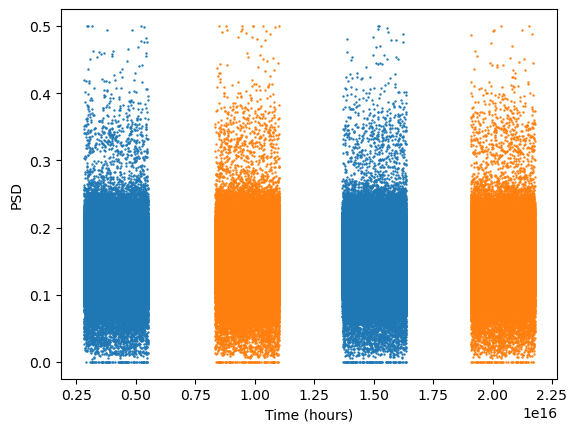

In [123]:
# Visualize time classification (optional, diagnostic)

# TODO simplify this into a timeline graph (how to do that?)
test = psd_report[psd_report["ECELL_ON"]]
test2 = psd_report[psd_report["ECELL_OFF"]]
plt.scatter(test["TIMETAG"], test["tail / total"], s=0.5)
plt.scatter(test2["TIMETAG"], test2["tail / total"], s=0.5)
plt.ylabel("PSD")
plt.xlabel("Time (hours)")

In [124]:
# Get neutron events during on/off periods
neutrons_ecell_on = psd_report.query("NASA & ECELL_ON")
neutrons_ecell_off = psd_report.query("NASA & ECELL_OFF")

## Fusion Analysis

In [29]:
# Function definition
# Experiment dataclass definition

def get_sigma_for_count(value: int) -> float:
    return np.sqrt(abs(value))

def get_sigma_for_count_delta(a:int, b:int) -> float:
    sigma_a = get_sigma_for_count(a)
    sigma_b = get_sigma_for_count(b)
    return np.sqrt(sigma_a**2 + sigma_b**2)

@dataclass
class Trial:
    """Class for storing trial data and calculating derived data"""
    condition_dataframe: pd.DataFrame
    background_dataframe: pd.DataFrame
    condition_time_bounds: tuple[int, int]
    background_time_bounds: tuple[int, int]
    
    EPSILON = 1e-6
    
    @property
    def condition_count(self) -> int:
        return self.condition_dataframe.shape[0]
    
    @property
    def background_count(self) -> int:
        return self.background_dataframe.shape[0]
    
    @property
    def condition_time(self) -> float:
        start, end = self.condition_time_bounds
        return (end - start) * 1e-12
    
    @property
    def background_time(self) -> float:
        start, end = self.background_time_bounds
        return (end - start) * 1e-12
    
    def count_delta(self):
        return self.condition_count - self.background_count

    def condition_rate(self):
        return self.condition_count/self.condition_time
    
    def background_rate(self):
        return self.background_count/self.background_time
    
    def rate_delta(self):
        return self.condition_rate() - self.background_rate()
    
    def rate_delta_is_valid(self):
        delta_time = abs(condition_time - background_time)
        return delta_time < self.EPSILON
    
    def condition_sigma(self):
        return np.sqrt(abs(self.condition_count))
    
    def background_sigma(self):
        return np.sqrt(abs(self.background_count))
    
    def delta_sigma(self):
        return np.sqrt(self.condition_sigma()**2 + self.background_sigma()**2)
    
    def condition_rate_sigma(self):
        return self.condition_sigma()/self.condition_time()
    
    def background_rate_sigma(self):
        return self.background_sigma()/self.background_time()
    
    def rate_delta_sigma(self):
        return np.sqrt(self.condition_rate_sigma()**2 + self.background_rate_sigma()**2)
    
    def report_count_statistics(self):
        print(f"Condition count: {self.condition_count}, SD: {self.condition_sigma():.4f}")
        print(f"Background count: {self.background_count}, SD: {self.background_sigma():.4f}")
        print(f"Count difference: {self.count_delta()}, SD: {self.delta_sigma():.4f}")
    
    def report_rate_statistics(self):
        print(f"Condition rate: {self.condition_rate():.4f}, SD: {self.condition_rate_sigma():.4f}")
        print(f"Background rate: {self.background_rate():.4f}, SD: {self.background_rate_sigma():.4f}")
        print(f"Rate difference: {self.rate_delta():.4f}, SD: {self.rate_delta_sigma():.4f}")
        print(f"Rate difference is{'' if self.rate_delta_is_valid() else ' not'} valid (times = {(self.condition_time, self.background_time)})")

### Overall Statistics

In [30]:
# Find overall on/off counts
# TODO do we need this? (Combines experiments, may not be valid, ask Luca)
total_count_ecell_on = neutrons_ecell_on.shape[0]
total_count_ecell_off = neutrons_ecell_off.shape[0]

# print(f"Overall count (E-cell on): {count_ecell_on}")
# print(f"Overall count (E-cell off): {count_ecell_off}")

overall = Experiment(total_count_ecell_on, total_count_ecell_off, 1, 1)
overall.report_count_statistics()

Condition count: 770, SD: 27.7489
Background count: 782, SD: 27.9643
Count difference: -12, SD: 39.3954


### Background Adjustment

In [31]:
# Adjust counts to remove background
# TODO Luca and Sergey need to talk about if this is needed
# background = 537.9135006958542 # TODO get recent background and fix this

# adjusted_ecell_on = total_count_ecell_on - background
# adjusted_ecell_off = total_count_ecell_off - background

# adjusted_sigma_on = get_sigma_for_count_delta(background, total_count_ecell_on)
# adjusted_sigma_off = get_sigma_for_count_delta(background, total_count_ecell_off)

# print(f"Background adjusted count (E-cell on): {adjusted_ecell_on:.4f}")
# print(f"Standard deviation for adjusted count (E-cell on): {adjusted_sigma_on:.4f}")
# print()
# print(f"Background adjusted count (E-cell off): {adjusted_ecell_off:.4f}")
# print(f"Standard deviation for adjusted count (E-cell off): {adjusted_sigma_off:.4f}")

### Count Rates

In [75]:
# Define dwell time (in seconds)
dwell_time = 60*1

In [80]:
# Get count histogram (and bins) for on/off periods

ecell_on_results = [
    counts_over_time_histogram(
        neutrons_ecell_on['TIMETAG'],
        dwell_time,
        *bounds
    )
    for bounds in on_bounds_timestamps
]
ecell_off_results = [
    counts_over_time_histogram(
        neutrons_ecell_off['TIMETAG'],
        dwell_time,
        *bounds
    )
    for bounds in off_bounds_timestamps
]

ecell_on_period_counts, ecell_on_period_bins = list(zip(*ecell_on_results))
ecell_off_period_counts, ecell_off_period_bins = list(zip(*ecell_off_results))

ecell_on_counts, ecell_on_bins = combine_period_histograms(ecell_on_period_counts, 
                                                           ecell_on_period_bins)
ecell_off_counts, ecell_off_bins = combine_period_histograms(ecell_off_period_counts, 
                                                             ecell_off_period_bins)

In [81]:
# Get count rates from count histogram
ecell_on_cps = ecell_on_counts/dwell_time
ecell_off_cps = ecell_off_counts/dwell_time

Text(0.5, 0, 'Time (s)')

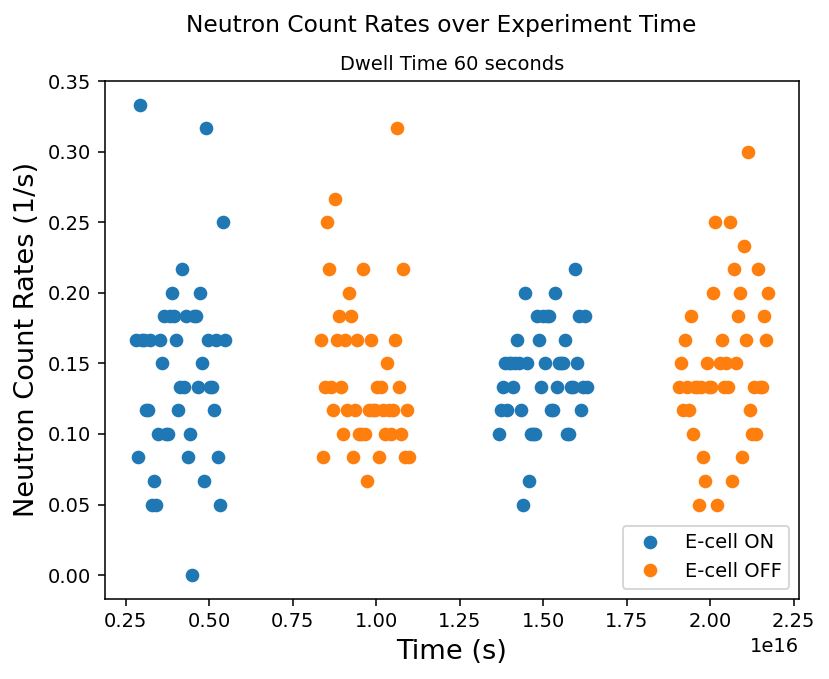

In [82]:
fig, ax = plot_histogram(
    [ecell_on_bins, ecell_off_bins],
    [ecell_on_cps, ecell_off_cps],
    labels=["E-cell ON", "E-cell OFF"]
)

# ax.set_title("Neutron Count Rates over Experiment Time (Dwell time 5 min)")
plt.suptitle("Neutron Count Rates over Experiment Time")
plt.title(f"Dwell Time {dwell_time} seconds", fontsize="medium")
ax.set_ylabel("Neutron Count Rates (1/s)", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [112]:
# Rearrange period counts/bins into experiments
ideal_columns = 4

trial_histo_sets = list(zip(
    ecell_on_period_counts, 
    ecell_off_period_counts, 
    ecell_on_period_bins,
    ecell_off_period_bins
))

In [114]:
# Get rate histogram per experiment

cps_n_bins = 20
cps_histograms = []

for histo_set in trial_histo_sets:
    cond_counts, bg_counts, cond_bins, bg_bins = histo_set

    cond_dwells = np.diff(cond_bins) * 1e-12
    bg_dwells = np.diff(bg_bins) * 1e-12
    cond_cps = cond_counts / cond_dwells
    bg_cps = bg_counts / bg_dwells
    
    cond_rate_counts, cond_rate_bins = np.histogram(cond_cps, cps_n_bins)
    bg_rate_counts, bg_rate_bins = np.histogram(bg_cps, cps_n_bins)
    
    cps_histograms.append((cond_rate_counts, bg_rate_counts, cond_rate_bins, bg_rate_bins))

Text(0.5, 1.0, 'Dwell Time 60 seconds, 20 Rate Bins')

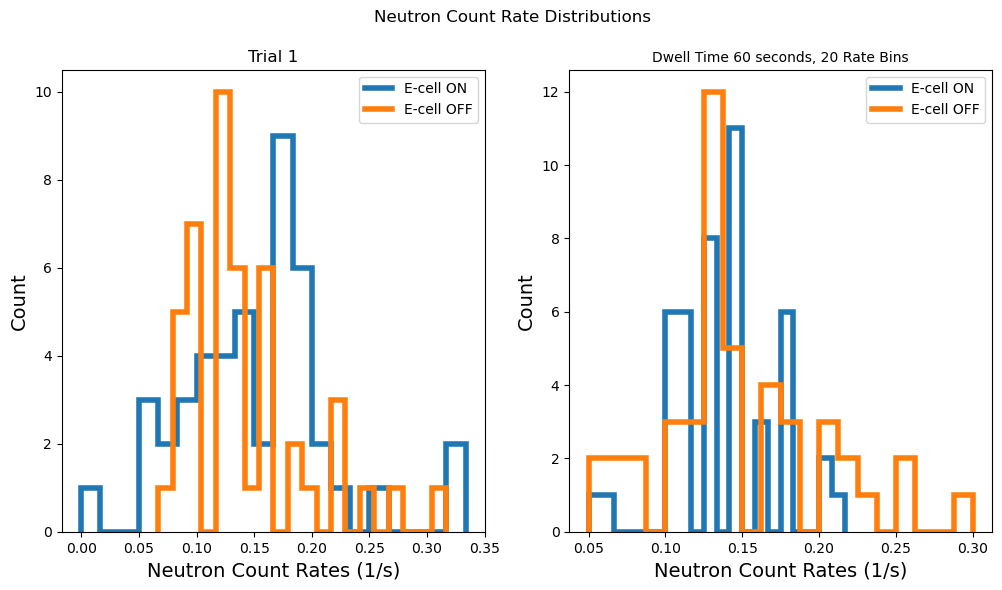

In [117]:
exp_count = len(experiment_histo_sets)
columns = min(exp_count, ideal_columns)
rows = -(-exp_count // ideal_columns)

fig, axs = plt.subplots(rows, columns, squeeze=False, figsize=(12, 6))
axs_flattened = [ax for row in axs for ax in row]

for i, (ax, trial_cps) in enumerate(list(zip(axs_flattened, cps_histograms))):
    cond_counts, bg_counts, cond_bins, bg_bins = trial_cps
    ax.stairs(cond_counts, cond_bins, label="E-cell ON", lw=4)
    ax.stairs(bg_counts, bg_bins, label="E-cell OFF", lw=4)
    ax.set_xlabel("Neutron Count Rates (1/s)", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.set_title(f"Trial {i+1}")
    ax.legend()
    
plt.suptitle("Neutron Count Rate Distributions")
plt.title(f"Dwell Time {dwell_time} seconds, {cps_n_bins} Rate Bins", fontsize="medium")

### Experiment Counts/Rates

In [122]:
# Determine total counts per period (and sigma values)

period_count_ecell_on = [
    neutrons_ecell_on[neutrons_ecell_on["TIMETAG"].between(on_start_timestamps[0], on_end_timestamps[0])].shape[0],
    neutrons_ecell_on[neutrons_ecell_on["TIMETAG"].between(on_start_timestamps[1], on_end_timestamps[1])].shape[0],
]

period_count_ecell_off = [
    neutrons_ecell_off[neutrons_ecell_off["TIMETAG"].between(off_start_timestamps[0], off_end_timestamps[0])].shape[0],
    neutrons_ecell_off[neutrons_ecell_off["TIMETAG"].between(off_start_timestamps[1], off_end_timestamps[1])].shape[0],
]

period_sigma_ecell_on = [np.sqrt(abs(count)) for count in period_count_ecell_on]
period_sigma_ecell_off = [np.sqrt(abs(count)) for count in period_count_ecell_off]

experiment_sets = list(zip(
    period_count_ecell_on, 
    period_count_ecell_off, 
    period_sigma_ecell_on, 
    period_sigma_ecell_off
))

for i, exp_set in enumerate(experiment_sets):
    count_on, count_off, sigma_on, sigma_off = exp_set
    delta = count_on-count_off
    delta_sigma = get_sigma_for_count_delta(count_on, count_off)
    print(f"Experiment {i+1}:")
    print(f"    Ecell On Count: {count_on},  SD: {sigma_on:.4f}")
    print(f"    Ecell Off Count: {count_off}, SD: {sigma_off:.4f}")
    print(f"    Count Difference: {delta}, SD: {delta_sigma:.4f}")
    print()

Experiment 1:
    Ecell On Count: 389,  SD: 19.7231
    Ecell Off Count: 381, SD: 19.5192
    Count Difference: 8, SD: 27.7489

Experiment 2:
    Ecell On Count: 381,  SD: 19.5192
    Ecell Off Count: 401, SD: 20.0250
    Count Difference: -20, SD: 27.9643



In [123]:
# period rates and rate sigmas and comparison
experiment_on_durations = [time_difference(end, start) for start, end in zip(on_start_times, on_end_times)]
experiment_off_durations = [time_difference(end, start) for start, end in zip(off_start_times, off_end_times)]
rate_ecell_on = [count/duration.total_seconds() for count, duration in zip(count_ecell_on, experiment_on_durations)]
rate_ecell_off = [count/duration.total_seconds() for count, duration in zip(count_ecell_off, experiment_off_durations)]

# experiment_rates = [on_rate - off_rate for on_rate, off_rate in zip(rate_ecell_on, rate_ecell_off)]

exp_sets_with_rates = list(zip(
    period_count_ecell_on, 
    period_count_ecell_off, 
    period_sigma_ecell_on, 
    period_sigma_ecell_off,
    experiment_on_durations,
    experiment_off_durations
))

for i, exp_set in enumerate(exp_sets_with_rates):
    count_on, count_off, sigma_on, sigma_off, on_time, off_time = exp_set
    on_time = on_time.total_seconds()
    off_time = off_time.total_seconds()
    rate_on = count_on/on_time
    rate_off = count_off/off_time
    rate_sigma_on = get_sigma_for_count(count_on)/on_time
    rate_sigma_off = get_sigma_for_count(count_off)/off_time
    rate_delta = rate_on-rate_off
    rate_delta_sigma = np.sqrt(rate_sigma_on**2 + rate_sigma_off**2)
    print(f"Experiment {i+1}:")
    print(f"    Ecell On Rate: {rate_on:.4f}, SD: {rate_sigma_on:.4f}")
    print(f"    Ecell Off Rate: {rate_off:.4f}, SD: {rate_sigma_off:.4f}")
    print(f"    Rate Difference: {rate_delta:.4f}, SD: {rate_delta_sigma:.4f}")
    print()

Experiment 1:
    Ecell On Rate: 0.1441, SD: 0.0073
    Ecell Off Rate: 0.1411, SD: 0.0072
    Rate Difference: 0.0030, SD: 0.0103

Experiment 2:
    Ecell On Rate: 0.1411, SD: 0.0072
    Ecell Off Rate: 0.1485, SD: 0.0074
    Rate Difference: -0.0074, SD: 0.0104



## NASA Classification Window (Remove?)

In [ ]:
# TODO re-do this to make CPS histogram per on/off experiment
# can't do until we re-do counts_over_time_histogram to work with on/off periods

In [ ]:
# Define dwell time
dwell_time = 60*5 # s

In [ ]:
%time
# Generate counts per dwell time

neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["NASA"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["NASA"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

In [ ]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

In [ ]:
# Determine count rate mean and standard deviation (2 methods)

total_count = psd_report.query("NASA == True").shape[0]
neutron_mean = np.average(neutron_time_cps)
neutron_count_sigma = np.sqrt(total_count)/total_time
neutron_cps_sigma = stat.stdev(neutron_time_cps)
print(f"Mean Count Rate: {neutron_mean:.4f} 1/s\nSigma (over all dwell rates): {neutron_cps_sigma:.4f} 1/s")
print(f"Count Rate Standard Deviation (using total count): {neutron_count_sigma:.4f} 1/s")

In [ ]:
%%time
# Plot neutron count rate over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins],#, gamma_time_bins],
    [neutron_time_cps],#, gamma_time_cps],
    labels=["Neutron CPS", "Non-Neutron CPS"],
    markersize =3,
)



#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, dwell = 5 min")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

In [ ]:
# Plot non-neutron (gamma ray) count rate over experiment run time
fig, ax = plot_histogram(
    [gamma_time_bins],
    [gamma_time_cps],
    labels=["Non-Neutron CPS"],
    markersize=3,
)

#ax.set_yscale('log')
ax.grid()
ax.set_title("Count Rate over Experiment Time, 5min dwell time")
ax.set_ylabel("Count Rate, 1/s", fontsize=14)
ax.set_xlabel("Time (hrs)", fontsize=14)
#ax.set_xlim(0.075, 0.25)

In [ ]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 450

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f} 1/s"

In [ ]:
# TODO determine if this is needed (since similar code exists above)
# neutron_mean = np.average(neutron_time_cps)
# neutron_sigma = np.sqrt(neutron_mean / len(neutron_time_cps))
# print(f"Mean: {neutron_mean}\nSigma: {neutron_sigma}")
# print(neutron_time_counts)

In [ ]:
# Plot count rate histogram for neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons"]
)


ax.grid()
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell time = {dwell_time}s")
ax.set_xlim(0.075, 0.25)

## Straight Edge

In [ ]:
# Define dwell time
dwell_time = 1 #s

In [ ]:
# Generate counts per dwell time
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["straight"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["straight"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

In [ ]:
# Plot counts per dwell over time (not needed)
# fig, ax = plot_histogram(
#     [neutron_time_bins, gamma_time_bins],
#     [neutron_time_counts, gamma_time_counts],
#     labels=["Neutron Counts", "Gamma Counts"]
# )

# ax.set_title("Event Counts per Dwell Time over Experiment Time")
# ax.set_ylabel("Event Counts", fontsize=14)
# ax.set_xlabel("Time (s)", fontsize=14)

In [ ]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

In [ ]:
# Plot count rates over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [ ]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

In [ ]:
# Plot count rate histogram for neutrons and non-neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Non-Neutrons"]
)


ax.grid()
# ax.set_ylim(0, 40)
# ax.set_xlim(100, 300)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time = {dwell_time}s")

# Covers

In [ ]:
# Define dwell time
dwell_time = 1 #s

In [ ]:
# Generate counts per dwell time
neutron_time_counts, neutron_time_bins = counts_over_time_histogram(
    psd_report[psd_report["neutron_cover"]]["TIMETAG"] * 1e-12, dwell_time, total_time
)

gamma_time_counts, gamma_time_bins = counts_over_time_histogram(
    psd_report[~psd_report["gamma_cover"]]["TIMETAG"]  * 1e-12, dwell_time, total_time
)

In [ ]:
# Plot counts per dwell over time (not needed)
# fig, ax = plot_histogram(
#     [neutron_time_bins, gamma_time_bins],
#     [neutron_time_counts, gamma_time_counts],
#     labels=["Neutron Counts", "Gamma Counts"]
# )

# ax.set_title("Event Counts per Dwell Time over Experiment Time")
# ax.set_ylabel("Event Counts", fontsize=14)
# ax.set_xlabel("Time (s)", fontsize=14)

In [ ]:
# Generate count rates for each dwell time bin
neutron_time_cps = neutron_time_counts / dwell_time
gamma_time_cps = gamma_time_counts / dwell_time

In [ ]:
# Plot count rates over experiment run time
fig, ax = plot_histogram(
    [neutron_time_bins, gamma_time_bins],
    [neutron_time_cps, gamma_time_cps],
    labels=["Neutron CPS", "Gamma CPS"]
)

ax.set_title("Count Rate over Experiment Time")
ax.set_ylabel("Count Rate", fontsize=14)
ax.set_xlabel("Time (s)", fontsize=14)

In [ ]:
# Create count rate histogram for neutrons and gamma rays
cps_n_bins = 124

neutron_cps_counts, neutron_cps_bins = np.histogram(neutron_time_cps, cps_n_bins)
gamma_cps_counts, gamma_cps_bins = np.histogram(gamma_time_cps, cps_n_bins)


f"CPS Bin Width: {gamma_cps_bins[2] - gamma_cps_bins[1]:.4f}s"

In [ ]:
# Plot count rate histogram for neutrons
fig, ax = plot_histogram(
    [neutron_cps_bins, gamma_cps_bins],
    [neutron_cps_counts, gamma_cps_counts],
    style="stairs",
    labels=["Neutrons", "Gammas"]
)


ax.grid()
# ax.set_xlim(100,400)
# ax.set_ylim(0,50)
ax.set_xlabel("CPS")
ax.set_ylabel("Counts")
ax.set_title(f"CPS histogram with dwell Time ={dwell_time}s")